# Edge Cases

Evaluated test cases:
- `BYZ-01`
- `BYZ-02`
- `SWEEP-01`
- `SWEEP-02`
- `SWEEP-03`

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("../../src").resolve()))
from faultlab.analysis import (
    load_csv,
    get_edge_case_boundary_matrix,
    QUARANTINE_COLORS,
)

EVALUATION_DIR = Path("../../tests/results/EVALUATION")
BASE_01_DIR = EVALUATION_DIR.joinpath("1_BASELINE/BASE_01")
EDGE_CASES_DIR = EVALUATION_DIR.joinpath("3_EDGE_CASES")
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Table 5: Edge Case Boundary Matrix

In [ ]:
boundary_df = get_edge_case_boundary_matrix(EDGE_CASES_DIR, BASE_01_DIR)
print("=== Table 5: Edge Case Boundary Matrix ===")
display(boundary_df)

=== Table 4: Edge Case Boundary Matrix ===


,Test Case,Total Transactions,Failover Success Rate (%),Signing Throughput (TPS),Throughput Degradation (%),Confirmed (Standard),Confirmed (Swept),Signing Retries
0,BYZ-01: MUTATE,5000,100.00,78.35,1.60,5000,0,402
1,BYZ-02: REPLAY,5000,100.00,49.02,38.45,5000,0,4986
2,SWEEP-01: CRASH_RES,5000,86.08,51.63,35.16,4304,696,6134
3,SWEEP-02: MUTATE,5000,88.98,43.50,45.38,4449,551,5470
4,SWEEP-03: SILENT_DROP_RES,5000,99.76,13.68,82.82,4988,12,1596


## 2. Ref: `BASE-01` Mempool Backlog

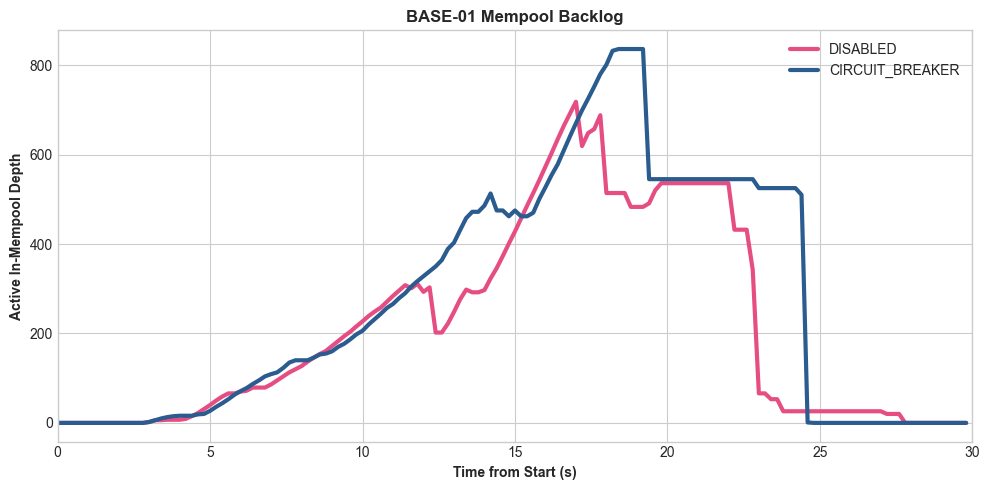

In [3]:
def fig_baseline_mempool():
    fig, ax = plt.subplots(figsize=(10, 5))
    time_points = np.arange(0, 30.0, 0.2)
    for pat, label, col in [("quarantine_disabled", "DISABLED", QUARANTINE_COLORS["DISABLED"]), ("quarantine_circuit_breaker", "CIRCUIT_BREAKER", QUARANTINE_COLORS["CIRCUIT_BREAKER"])]:
        files = sorted(list(BASE_01_DIR.glob(f"*{pat}*.csv")))
        if not files:
            continue
        curves = []
        for file_path in files:
            df = load_csv(file_path)
            t0 = df["created_at"].min()
            sub_s = (df["submitted_at"] - t0).dt.total_seconds().dropna().values
            conf_s = (df["confirmed_at"] - t0).dt.total_seconds().dropna().values
            c = [((sub_s <= t) & (conf_s > t)).sum() for t in time_points]
            curves.append(c)
        ax.plot(time_points, np.median(curves, axis=0), color=col, linewidth=3, label=label)
    ax.set_title("BASE-01 Mempool Backlog", fontweight="bold")
    ax.set_xlabel("Time from Start (s)", fontweight="bold")
    ax.set_ylabel("Active In-Mempool Depth", fontweight="bold")
    ax.set_xlim(0, 30.0)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

fig_baseline_mempool()

## 3. Figure 6: Nonce Gap Sweeper Efficiency Under `SWEEP-00` vs `SWEEP-01: CRASH_RES`

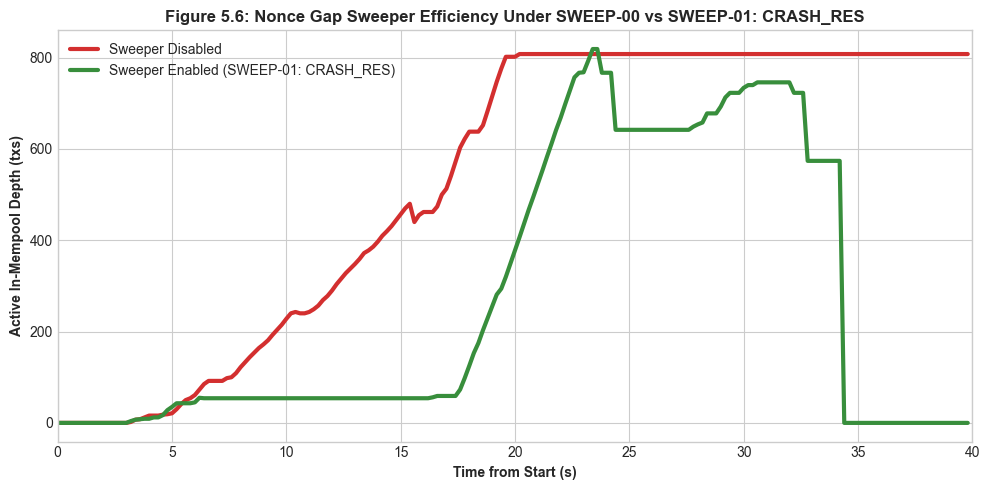

In [4]:
def fig_6():
    sweep_00_dir = EDGE_CASES_DIR.joinpath("SWEEP_00")
    sweep_01_dir = EDGE_CASES_DIR.joinpath("SWEEP_01")

    time_points = np.arange(0, 40.0, 0.2)
    fig, ax = plt.subplots(figsize=(10, 5))

    configs = [
        (sweep_00_dir, "*.csv", "Sweeper Disabled", "#d32f2f"),
        (sweep_01_dir, "*CRASH_RES*.csv", "Sweeper Enabled (SWEEP-01: CRASH_RES)", "#388e3c"),
    ]

    for folder, pat, label, color in configs:
        files = sorted(list(folder.glob(pat)))
        if not files:
            continue
        curves = []
        for file_path in files:
            df = load_csv(file_path)
            t0 = df["created_at"].min()
            sub_s = (df["submitted_at"] - t0).dt.total_seconds().values
            conf_s = (df["confirmed_at"] - t0).dt.total_seconds().fillna(np.inf).values
            # Filter un-submitted transactions strictly for SWEEP-00: since the gap sweeper is
            # disabled and threshold signing faults are injected, some transactions entirely fail
            # to produce a signature and stall in CRYPTOGRAPHIC_ABORT state (submitted_at = NaN).
            if folder.name == "SWEEP_00":
                valid = ~np.isnan(sub_s)
                sub_s = sub_s[valid]
                conf_s = conf_s[valid]
            c = [((sub_s <= t) & (conf_s > t)).sum() for t in time_points]
            curves.append(c)

        ax.plot(time_points, np.median(curves, axis=0), color=color, linewidth=3.0, label=label)

    ax.set_title("Figure 5.6: Nonce Gap Sweeper Efficiency Under SWEEP-00 vs SWEEP-01: CRASH_RES", fontweight="bold")
    ax.set_xlabel("Time from Start (s)", fontweight="bold")
    ax.set_ylabel("Active In-Mempool Depth (txs)", fontweight="bold")
    ax.set_xlim(0, 40.0)
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR.joinpath("FIG_6_Sweeper_Mempool.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

fig_6()